## Question 1: Bernoulli Sample Data

### Part 1: Likelihood Function

We are given Bernoulli sample data: `1, 0, 1, 1, 0, 1, 0, 1`.

The likelihood function for $n$ independent Bernoulli trials is given by:

$$ L(p; \text{data}) = \prod_{i=1}^{n} P(x_i; p) = p^k (1-p)^{n-k} $$

where:
- $p$ is the probability of success (getting a '1').
- $k$ is the number of successes in the sample.
- $n$ is the total number of trials.

We will write a function to compute this likelihood for a given $p$ and evaluate it for $p$ values from 0.1 to 0.9 to find the $p$ that maximizes the likelihood.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Bernoulli sample data
data = [1, 0, 1, 1, 0, 1, 0, 1]

def likelihood(p, data):

    # Count successes (1s) and total trials
    k = sum(data)
    n = len(data)

    # Handle edge cases for p to avoid log(0) issues later for log-likelihood
    # and ensure p is within (0, 1) for calculations.
    if not (0 < p < 1):
        return 0.0 # Likelihood is 0 if p is 0 or 1, or outside range

    # Likelihood formula: p^k * (1-p)^(n-k)
    return (p ** k) * ((1 - p) ** (n - k))

# Evaluate likelihood for different values of p (0.1 to 0.9)
p_values = [i / 10 for i in range(1, 10)] # [0.1, 0.2, ..., 0.9]
likelihood_values = [likelihood(p, data) for p in p_values]

# Find the p that maximizes the likelihood
max_likelihood = -1
max_p = None

for i in range(len(p_values)):
    if likelihood_values[i] > max_likelihood:
        max_likelihood = likelihood_values[i]
        max_p = p_values[i]

print(f"Bernoulli Sample Data: {data}")
print(f"p values: {p_values}")
print(f"Likelihood values: {likelihood_values}")
print(f"Value of p that maximizes the likelihood: {max_p} (Likelihood: {max_likelihood:.4f})")

Bernoulli Sample Data: [1, 0, 1, 1, 0, 1, 0, 1]
p values: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
Likelihood values: [7.290000000000003e-06, 0.00016384000000000008, 0.0008334899999999996, 0.00221184, 0.00390625, 0.00497664, 0.004537890000000001, 0.002621439999999999, 0.0005904899999999997]
Value of p that maximizes the likelihood: 0.6 (Likelihood: 0.0050)


### Part 2: Log-Likelihood Function and Plotting

Now, we modify the program to compute the log-likelihood function instead of the likelihood. The log-likelihood function for Bernoulli trials is:

$$ \log L(p; \text{data}) = \log(p^k (1-p)^{n-k}) = k \log(p) + (n-k) \log(1-p) $$

Using the log-likelihood is often preferred in optimization because it converts products into sums, which are easier to differentiate, and avoids numerical underflow issues that can occur with very small likelihood values. The value of $p$ that maximizes the log-likelihood will also maximize the likelihood.

We will also plot the log-likelihood versus $p$ using Matplotlib to visually identify the maximum.

Value of p that maximizes the log-likelihood: 0.62 (Log-Likelihood: -5.2925)


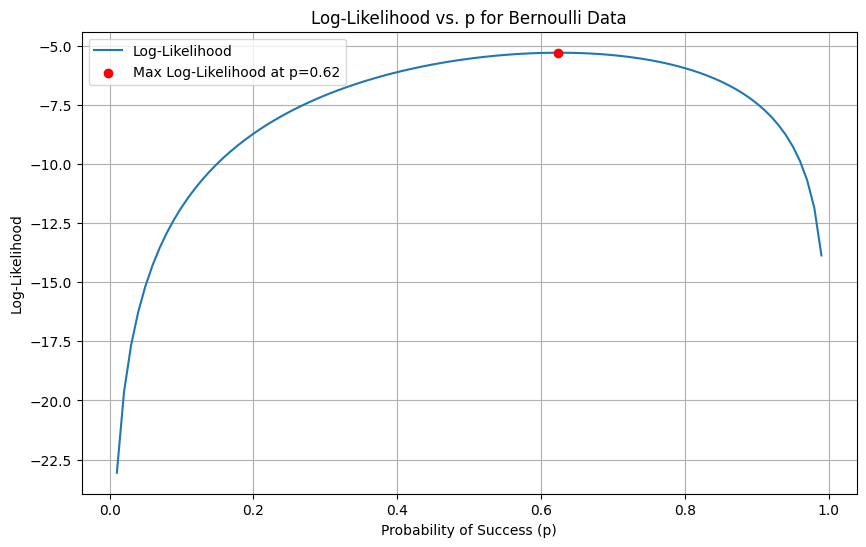

In [ ]:
# Bernoulli sample data (from previous part)
data = [1, 0, 1, 1, 0, 1, 0, 1]

def log_likelihood(p, data):

    k = sum(data)
    n = len(data)

    # Ensure p is strictly between 0 and 1 to avoid log(0) errors
    if p <= 0 or p >= 1:
        return -np.inf # Log-likelihood is negative infinity at boundaries

    # Log-likelihood formula: k*log(p) + (n-k)*log(1-p)
    return (k * np.log(p)) + ((n - k) * np.log(1 - p))

# Evaluate log-likelihood for a finer range of p values for a smoother plot
p_plot_values = np.linspace(0.01, 0.99, 100) # From 0.01 to 0.99 for smooth plot
log_likelihood_values = [log_likelihood(p, data) for p in p_plot_values]

# Find the p that maximizes the log-likelihood
max_log_likelihood = -np.inf
max_p_log = None

for i in range(len(p_plot_values)):
    if log_likelihood_values[i] > max_log_likelihood:
        max_log_likelihood = log_likelihood_values[i]
        max_p_log = p_plot_values[i]

print(f"Value of p that maximizes the log-likelihood: {max_p_log:.2f} (Log-Likelihood: {max_log_likelihood:.4f})")

# Plot log-likelihood vs p
plt.figure(figsize=(10, 6))
plt.plot(p_plot_values, log_likelihood_values, label='Log-Likelihood')
plt.scatter(max_p_log, max_log_likelihood, color='red', zorder=5, label=f'Max Log-Likelihood at p={max_p_log:.2f}')
plt.title('Log-Likelihood vs. p for Bernoulli Data')
plt.xlabel('Probability of Success (p)')
plt.ylabel('Log-Likelihood')
plt.grid(True)
plt.legend()
plt.show()

## Question 2: Poisson Parameter Estimation (MLE)

We are given data representing the number of arrivals per minute: `3, 2, 4, 1, 3, 2, 5, 3`.

For a Poisson distribution, the Maximum Likelihood Estimator (MLE) for the parameter $\lambda$ (the average rate of events) is simply the sample mean of the observed data.

$$ \hat{\lambda}_{MLE} = \frac{1}{n} \sum_{i=1}^{n} x_i $$

where:
- $n$ is the number of observations.
- $x_i$ is each individual observation.

In [ ]:
# Arrival data
arrival_data = [3, 2, 4, 1, 3, 2, 5, 3]

# Estimate the Poisson parameter lambda using MLE (sample mean)
lambda_mle = sum(arrival_data) / len(arrival_data)

print(f"Arrival Data: {arrival_data}")
print(f"Estimated Poisson parameter λ (MLE): {lambda_mle:.2f}")

# Verify the result using NumPy mean
np_mean = np.mean(arrival_data)
print(f"Verified using NumPy mean: {np_mean:.2f}")

if np.isclose(lambda_mle, np_mean):
    print("The MLE estimate matches the NumPy mean, as expected.")

Arrival Data: [3, 2, 4, 1, 3, 2, 5, 3]
Estimated Poisson parameter λ (MLE): 2.88
Verified using NumPy mean: 2.88
The MLE estimate matches the NumPy mean, as expected.


## Question 3: Exponential Distribution Parameter Estimation (MLE)

We are given lifetime data (in hours): `120, 150, 200, 180, 160`.

For an exponential distribution with probability density function (PDF):

$$ f(x; \lambda) = \lambda e^{-\lambda x} \quad \text{for } x \ge 0 $$

where $\lambda$ is the rate parameter.

The Maximum Likelihood Estimator (MLE) for the rate parameter $\lambda$ of an exponential distribution is the reciprocal of the sample mean:

$$ \hat{\lambda}_{MLE} = \frac{1}{\bar{x}} = \frac{n}{\sum_{i=1}^{n} x_i } $$

where:
- $\bar{x}$ is the sample mean.
- $n$ is the number of observations.
- $x_i$ is each individual lifetime observation.

In [ ]:
# Lifetime data
lifetime_data = [120, 150, 200, 180, 160]

# Calculate the sample mean
sample_mean = np.mean(lifetime_data)

# Estimate parameter lambda of exponential distribution using MLE
# The MLE for lambda is 1 / sample_mean
lambda_exp_mle = 1 / sample_mean

print(f"Lifetime Data: {lifetime_data}")
print(f"Sample Mean (x̄): {sample_mean:.2f}")
print(f"Estimated Exponential parameter λ (MLE): {lambda_exp_mle:.4f}")

print("\nExplanation of the formula used:")
print("The formula for the MLE of the rate parameter λ (lambda) in an exponential distribution is 1 divided by the sample mean (1/x̄). This is derived by taking the likelihood function for the exponential distribution, finding its logarithm (log-likelihood), taking the derivative with respect to λ, setting it to zero, and solving for λ.")

Lifetime Data: [120, 150, 200, 180, 160]
Sample Mean (x̄): 162.00
Estimated Exponential parameter λ (MLE): 0.0062

Explanation of the formula used:
The formula for the MLE of the rate parameter λ (lambda) in an exponential distribution is 1 divided by the sample mean (1/x̄). This is derived by taking the likelihood function for the exponential distribution, finding its logarithm (log-likelihood), taking the derivative with respect to λ, setting it to zero, and solving for λ.
